# 🏦 Banking NLP — Loan Approval Sentiment Analyser
### 📝 Learner Worksheet

---

## 📌 Project Overview

When a bank approves or rejects a loan, customers leave feedback.  
Your job is to analyse that feedback using NLP to answer:

- **How do customers FEEL about their loan decision?**
- **What words do they use most?**

## 📋 Your 6 Tasks

| Task | What You Will Do | Concept |
|------|-----------------|----------|
| Task 1 | Load and explore the dataset | Pandas, JSON |
| Task 2 | Clean raw text | Regex |
| Task 3 | Tokenize and filter words | Basic NLP — NLTK |
| Task 4 | Score sentiment | VADER + TextBlob |
| Task 5 | Classify into 4 business groups | Logic + Sentiment |
| Task 6 | Visualise the results | Matplotlib + WordCloud |

---

### 📖 How to use this worksheet
- Each task has an explanation of **what to do** and **why**
- Code cells have **blanks marked with `____`** for you to fill in
- **Hints** are provided inside comments
- Run each cell after completing it to check your work

---

## ⚙️ Setup — Install and Import Libraries

**Run this cell first — do not change anything here.**

In [71]:
!pip install vaderSentiment textblob wordcloud nltk pandas matplotlib -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ All libraries ready!")

✅ All libraries ready!


In [72]:
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

print("✅ Imports done!")

✅ Imports done!


---
## 📋 Task 1 — Load and Explore the Dataset

### What to do
The customer feedback data is stored as **JSON** (the format real APIs return).  
You need to:
1. Parse the JSON string into a Python list using `json.loads()`
2. Convert that list into a Pandas DataFrame
3. Explore the data using `.head()` and `.info()`

### Key concept — JSON to DataFrame
```
JSON string  →  json.loads()  →  Python list of dicts  →  pd.DataFrame()  →  Table
```

### Dataset columns
| Column | Meaning |
|---|---|
| `customer_id` | Unique customer ID |
| `loan_status` | Approved or Rejected |
| `feedback` | What the customer said |

In [73]:
# ── The dataset is given to you — do not change this ─────────────
api_response = json.dumps([
    {"customer_id": "C001", "loan_status": "Approved",  "feedback": "I am so happy my loan got approved! The process was smooth and the staff were very helpful."},
    {"customer_id": "C002", "loan_status": "Rejected",  "feedback": "Very disappointed. My loan was rejected without a clear reason. Terrible service."},
    {"customer_id": "C003", "loan_status": "Approved",  "feedback": "Great news! Loan approved quickly. Excellent support from the bank team."},
    {"customer_id": "C004", "loan_status": "Rejected",  "feedback": "Unfair decision. I submitted all documents but still got rejected. Very frustrated."},
    {"customer_id": "C005", "loan_status": "Approved",  "feedback": "Wonderful experience. Got approved within 2 days. Will recommend to friends."},
    {"customer_id": "C006", "loan_status": "Approved",  "feedback": "The approval was fast but the interest rate is too high. Not entirely satisfied."},
    {"customer_id": "C007", "loan_status": "Rejected",  "feedback": "I understand the rejection but wish the bank had explained the reason better."},
    {"customer_id": "C008", "loan_status": "Approved",  "feedback": "Happy with the approval. The EMI plan is flexible and manageable."},
    {"customer_id": "C009", "loan_status": "Rejected",  "feedback": "Shocking rejection after waiting 3 weeks. Waste of time and very unprofessional."},
    {"customer_id": "C010", "loan_status": "Approved",  "feedback": "Finally approved after two attempts. The second time the process was much clearer."},
    {"customer_id": "C011", "loan_status": "Rejected",  "feedback": "Rejection was expected but the communication was poor. No follow up call received."},
    {"customer_id": "C012", "loan_status": "Approved",  "feedback": "Brilliant service. Loan approved faster than expected. Very professional team."},
    {"customer_id": "C013", "loan_status": "Rejected",  "feedback": "Deeply upset about the rejection. I needed this loan urgently for medical expenses."},
    {"customer_id": "C014", "loan_status": "Approved",  "feedback": "Approval received but the paperwork was excessive and confusing for a first-time applicant."},
    {"customer_id": "C015", "loan_status": "Rejected",  "feedback": "The rejection letter was polite and the bank suggested ways to improve my application."},
    {"customer_id": "C016", "loan_status": "Approved",  "feedback": "Very satisfied. Interest rate is fair and the repayment schedule suits my income."},
    {"customer_id": "C017", "loan_status": "Rejected",  "feedback": "Frustrated with the outcome. Applied twice and got rejected both times with no explanation."},
    {"customer_id": "C018", "loan_status": "Approved",  "feedback": "Good experience overall. Minor delays in documentation but final approval was smooth."},
    {"customer_id": "C019", "loan_status": "Rejected",  "feedback": "Neutral about it. The rejection was fair given my current credit score situation."},
    {"customer_id": "C020", "loan_status": "Approved",  "feedback": "Thrilled with the quick approval. The bank manager personally called to congratulate me."}
])

# ── YOUR TASK ────────────────────────────────────────────────────
# Step 1: Parse the JSON string into a Python list
# Hint: use json.loads(api_response)
data = json.loads(api_response)

print(json.loads(api_response))
# Step 2: Convert the list into a Pandas DataFrame
# Hint: use pd.DataFrame(data)
df = pd.DataFrame(data)

df.head()

# Step 3: Print how many rows and the loan status counts
# Hint: len(df) gives number of rows
print(f"Total records: {len(df)}")
print(f"Approved: {(df['loan_status']=='Approved').sum()}")
print(f"Rejected: {(df['loan_status']=='Rejected').sum()}")

[{'customer_id': 'C001', 'loan_status': 'Approved', 'feedback': 'I am so happy my loan got approved! The process was smooth and the staff were very helpful.'}, {'customer_id': 'C002', 'loan_status': 'Rejected', 'feedback': 'Very disappointed. My loan was rejected without a clear reason. Terrible service.'}, {'customer_id': 'C003', 'loan_status': 'Approved', 'feedback': 'Great news! Loan approved quickly. Excellent support from the bank team.'}, {'customer_id': 'C004', 'loan_status': 'Rejected', 'feedback': 'Unfair decision. I submitted all documents but still got rejected. Very frustrated.'}, {'customer_id': 'C005', 'loan_status': 'Approved', 'feedback': 'Wonderful experience. Got approved within 2 days. Will recommend to friends.'}, {'customer_id': 'C006', 'loan_status': 'Approved', 'feedback': 'The approval was fast but the interest rate is too high. Not entirely satisfied.'}, {'customer_id': 'C007', 'loan_status': 'Rejected', 'feedback': 'I understand the rejection but wish the bank

In [74]:
# ── YOUR TASK ────────────────────────────────────────────────────
# Show the first 5 rows of the DataFrame
# Hint: use df.head(____)
df.head(5)

,customer_id,loan_status,feedback
0,C001,Approved,I am so happy my loan got approved! The proces...
1,C002,Rejected,Very disappointed. My loan was rejected withou...
2,C003,Approved,Great news! Loan approved quickly. Excellent s...
3,C004,Rejected,Unfair decision. I submitted all documents but...
4,C005,Approved,Wonderful experience. Got approved within 2 da...


---
## 🔧 Task 2 — Clean Text Using Regex

### What to do
Customer feedback contains punctuation, numbers, and symbols that interfere with NLP.  
Write a `clean_text()` function using regex to:
1. Remove anything that is NOT a letter or space
2. Collapse multiple spaces into one
3. Strip whitespace from ends and convert to lowercase

### Regex patterns to use
| Pattern | What it does |
|---|---|
| `[^a-zA-Z\s]` | Matches anything that is NOT a letter or space |
| `\s+` | Matches one or more whitespace characters |

### Expected output
```
Input:  "I am so happy! Loan approved in 2 days."
Output: "i am so happy loan approved in days"
```

In [75]:
pattern = {
    "url" : re.compile(r'https:?//\S+'),
    "extra_space":re.compile(r'\s+'),
    "html_tag" : re.compile(r'<[^>]+>'),
    "punctuation" : re.compile(r'[^a-zA-Z\s]'),
    "ticker":  re.compile(r'\b[A-Z]{2,5}\b'),
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),
    "number":      re.compile(r'[\d\s]+'),
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),
    "extra_chars": re.compile(r'[!,.]\s')
}

def clean_text(text:str) ->str:
    text = pattern["url"].sub(" ", text)
    text = pattern["extra_space"].sub(" ", text)
    text = pattern["html_tag"].sub(" ", text)
    text = pattern["punctuation"].sub(" ", text)
    text = pattern["ticker"].sub(" ", text)
    text = pattern["number"].sub(" ", text)
    text = pattern["extra_chars"].sub(" ",text)
    return text.strip().lower()

def extract_proper_nouns(text: str) -> list:
    return pattern["proper_noun"].findall(text)


def extract_tickers(text: str) -> list:
    return pattern["ticker"].findall(text)

df['clean_text'] = df['feedback'].apply(clean_text)
df["proper_noun"] = df['feedback'].apply(extract_proper_nouns) 
df["ticker"] = df['feedback'].apply(extract_tickers) 
df.head()

print("ORIGINAL:\n", df['feedback'].iloc[4][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[4][:300])

ORIGINAL:
 Wonderful experience. Got approved within 2 days. Will recommend to friends.

CLEANED:
 wonderful experience got approved within days will recommend to friends


---
## 🧠 Task 3 — Tokenize and Remove Stopwords

### What to do
Break each cleaned sentence into individual words, then remove common words that carry no meaning.

### Steps inside `tokenize_and_filter()`
1. `word_tokenize(text)` — splits sentence into word list
2. Keep only alphabetic tokens — `token.isalpha()`
3. Remove stopwords — check if token is NOT in `STOP_WORDS`
4. Remove very short tokens — keep only words longer than 2 characters

### After tokenizing — use FreqDist
Flatten all token lists into one big list, then count word frequencies.

### Expected output (example)
```
Input : "i am so happy loan approved quickly"
Tokens: ['happy', 'approved', 'quickly']
```

Total Tokens Count: 156
Top word: [('rejection', 6), ('loan', 5), ('approved', 5), ('approval', 5), ('got', 4), ('bank', 4), ('rejected', 3), ('time', 3), ('happy', 2), ('process', 2), ('smooth', 2), ('reason', 2), ('service', 2), ('team', 2), ('frustrated', 2), ('experience', 2), ('interest', 2), ('rate', 2), ('satisfied', 2), ('expected', 2)]


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'rejection'),
  Text(1, 0, 'loan'),
  Text(2, 0, 'approved'),
  Text(3, 0, 'approval'),
  Text(4, 0, 'got'),
  Text(5, 0, 'bank'),
  Text(6, 0, 'rejected'),
  Text(7, 0, 'time'),
  Text(8, 0, 'happy'),
  Text(9, 0, 'process'),
  Text(10, 0, 'smooth'),
  Text(11, 0, 'reason'),
  Text(12, 0, 'service'),
  Text(13, 0, 'team'),
  Text(14, 0, 'frustrated'),
  Text(15, 0, 'experience'),
  Text(16, 0, 'interest'),
  Text(17, 0, 'rate'),
  Text(18, 0, 'satisfied'),
  Text(19, 0, 'expected')])

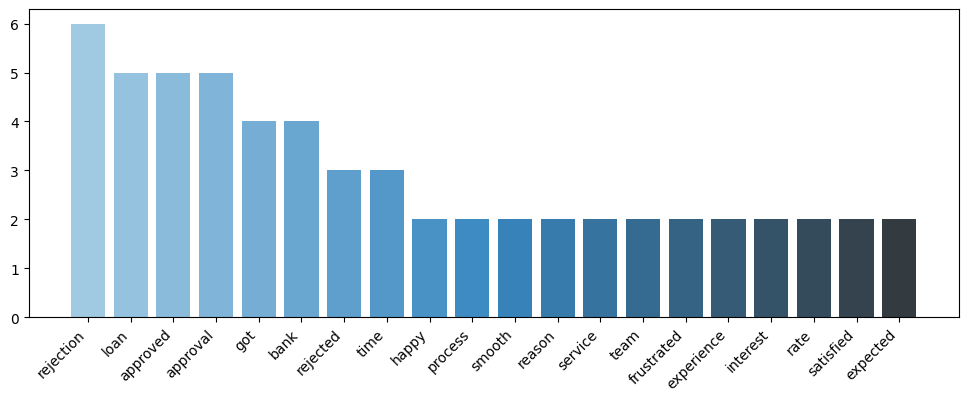

In [76]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

stop_words = set(stopwords.words('english'))

def tokenize_and_filter(text:str) ->list:
    tokens = word_tokenize(text)
    tokens = [i for i in tokens if i.isalpha()]
    tokens = [i for i in tokens if i not in stop_words]
    tokens = [i for i in tokens if len(i)>2]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_and_filter)
df.head()

all_tokens = [tokens for i in df['tokens'] for tokens in i]
freq_dict = FreqDist(all_tokens)
top_words = freq_dict.most_common(20)

word, count = zip(*top_words)

print(f'Total Tokens Count: {len(all_tokens)}')
print(f'Top word: {top_words}')

plt.figure(figsize=(12,4))
bars = plt.bar(word,count,color=sns.color_palette("Blues_d", 20))
plt.xticks(rotation=45, ha='right', fontsize=10)

---
## 💬 Task 4 — Sentiment Scoring with VADER and TextBlob

### What to do
Score each customer's feedback using both VADER and TextBlob, then build a **consensus label**.

### VADER rules
- `compound >= 0.05` → `'Positive'`
- `compound <= -0.05` → `'Negative'`
- Otherwise → `'Neutral'`
- Feed VADER the **original `feedback`** column (not cleaned text)

### TextBlob rules
- `polarity > 0.05` → `'Positive'`
- `polarity < -0.05` → `'Negative'`
- Otherwise → `'Neutral'`

### Consensus rule
- Both agree → use that label
- One says Neutral → use the other tool's label
- They conflict → `'Neutral'`

In [77]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_analysis(text:str) ->dict:
    score = vader.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        label='Positive'
    elif compound <= -0.05:
        label='Negative'
    else:
        label='Netural'
    return {
        'vader_compound' :compound,
        'vader_pos' : score['pos'],
        'vader_neu' : score['neu'],
        'vader_neg' : score['neg'],
        'vader_label': label,
    }

def text_analysis(text:str)->dict:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.5:
        label = 'Positive'
    elif pol < -0.5:
        label = 'Negative'
    else:
        label = 'Netural'
    return {
        'tb_pol' :pol,
        'tb_subj' : subj,
        'tb_label': label,
    }

df.head()
vader_results = df['clean_text'].apply(vader_analysis).apply(pd.Series)
textblob_result = df['clean_text'].apply(text_analysis).apply(pd.Series)

print("Running sentiment analysis...")

df = pd.concat([df,vader_results,textblob_result],axis=1)
df.head()

Running sentiment analysis...


,customer_id,loan_status,feedback,clean_text,proper_noun,ticker,tokens,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_pol,tb_subj,tb_label
0,C001,Approved,I am so happy my loan got approved! The proces...,i am so happy my loan got approved the process...,[],[],"[happy, loan, got, approved, process, smooth, ...",0.8918,0.415,0.585,0.000,Positive,0.466667,0.600000,Netural
1,C002,Rejected,Very disappointed. My loan was rejected withou...,very disappointed my loan was rejected without...,[],[],"[disappointed, loan, rejected, without, clear,...",-0.8996,0.000,0.400,0.600,Negative,-0.625000,0.786111,Negative
2,C003,Approved,Great news! Loan approved quickly. Excellent s...,great news loan approved quickly excellent sup...,[],[],"[great, news, loan, approved, quickly, excelle...",0.9231,0.655,0.345,0.000,Positive,0.900000,0.875000,Positive
3,C004,Rejected,Unfair decision. I submitted all documents but...,unfair decision i submitted all documents but ...,[],[],"[unfair, decision, submitted, documents, still...",-0.9107,0.000,0.438,0.562,Negative,-0.705000,0.630000,Negative
4,C005,Approved,Wonderful experience. Got approved within 2 da...,wonderful experience got approved within days ...,[],[],"[wonderful, experience, got, approved, within,...",0.9022,0.669,0.331,0.000,Positive,1.000000,1.000000,Positive


In [78]:
# ── Build the consensus label ─────────────────────────────────────
def consensus(row):
    v = row['vader_label']
    t = row['tb_label']

    # Case 1: both agree
    if v == t:
        return v   # Hint: return v

    # Case 2: VADER is Neutral — trust TextBlob
    if v == 'Neutral':
        return t  # Hint: return t

    # Case 3: TextBlob is Neutral — trust VADER
    if t == 'Neutral':
        return v  # Hint: return v

    # Case 4: conflict
    return 'Neutral'


df['sentiment'] = df.apply(consensus, axis=1)

print("Consensus sentiment distribution:")
print(df['sentiment'].value_counts())

Consensus sentiment distribution:
sentiment
Neutral     13
Positive     4
Negative     3
Name: count, dtype: int64


---
## 🏷️ Task 5 — Classify into 4 Business Groups

### What to do
Combine `loan_status` and `sentiment` to create a `customer_group` column with 4 labels:

| Condition | Group Label |
|---|---|
| Approved + Positive | `'Approved — Positive'` |
| Approved + Negative or Neutral | `'Approved — Negative'` |
| Rejected + Positive | `'Rejected — Positive'` |
| Rejected + Negative or Neutral | `'Rejected — Negative'` |

### Why is this useful?
The bank can use these groups to take different actions:  
Approved-Positive → send referral offer | Rejected-Negative → priority callback

In [79]:
def classify(row):
    if row['loan_status'] == 'Approved':
        if row['sentiment'] == 'Positive':
            return 'Approved — Positive'
        elif row['sentiment'] == 'Neutral':
            return 'Approved — Neutral'
        else:
            return 'Approved — Negative'
    elif row['loan_status'] == 'Rejected':
        if row['sentiment'] == 'Positive':
            return 'Rejected — Positive'
        elif row['sentiment'] == 'Neutral':
            return 'Rejected — Neutral'
        else:
            return 'Rejected — Negative'
    return 'Unknown'

df['customer_group'] = df.apply(classify, axis=1)

df.head()

,customer_id,loan_status,feedback,clean_text,proper_noun,ticker,tokens,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_pol,tb_subj,tb_label,sentiment,customer_group
0,C001,Approved,I am so happy my loan got approved! The proces...,i am so happy my loan got approved the process...,[],[],"[happy, loan, got, approved, process, smooth, ...",0.8918,0.415,0.585,0.000,Positive,0.466667,0.600000,Netural,Neutral,Approved — Neutral
1,C002,Rejected,Very disappointed. My loan was rejected withou...,very disappointed my loan was rejected without...,[],[],"[disappointed, loan, rejected, without, clear,...",-0.8996,0.000,0.400,0.600,Negative,-0.625000,0.786111,Negative,Negative,Rejected — Negative
2,C003,Approved,Great news! Loan approved quickly. Excellent s...,great news loan approved quickly excellent sup...,[],[],"[great, news, loan, approved, quickly, excelle...",0.9231,0.655,0.345,0.000,Positive,0.900000,0.875000,Positive,Positive,Approved — Positive
3,C004,Rejected,Unfair decision. I submitted all documents but...,unfair decision i submitted all documents but ...,[],[],"[unfair, decision, submitted, documents, still...",-0.9107,0.000,0.438,0.562,Negative,-0.705000,0.630000,Negative,Negative,Rejected — Negative
4,C005,Approved,Wonderful experience. Got approved within 2 da...,wonderful experience got approved within days ...,[],[],"[wonderful, experience, got, approved, within,...",0.9022,0.669,0.331,0.000,Positive,1.000000,1.000000,Positive,Positive,Approved — Positive


---
## 📊 Task 6 — Visualise Results

### What to do
Create three charts:
1. **Bar chart** — count of customers in each of the 4 groups
2. **Word cloud** — most common words in negative feedback
3. **Scatter plot** — VADER compound vs TextBlob polarity per customer

### Colour guide for bar chart
| Group | Colour |
|---|---|
| Approved — Positive | `'#2ecc71'` (green) |
| Approved — Negative | `'#f39c12'` (orange) |
| Rejected — Positive | `'#3498db'` (blue) |
| Rejected — Negative | `'#e74c3c'` (red) |

Group Count:
 customer_group
Approved — Neutral     7
Rejected — Neutral     6
Approved — Positive    4
Rejected — Negative    3
Name: count, dtype: int64
('Approved — Neutral', 'Rejected — Neutral', 'Approved — Positive', 'Rejected — Negative') (np.int64(7), np.int64(6), np.int64(4), np.int64(3))


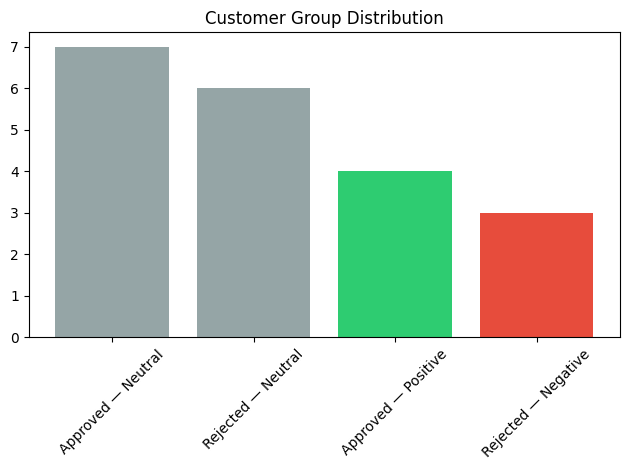

In [80]:
# ── Chart 1: Bar chart of customer groups ────────────────────────
# Step 1: Count customers per group
# Hint: df['customer_group'].value_counts()
group_counts = df['customer_group'].value_counts()
print(f'Group Count:\n',group_counts)

labels, values = zip(*zip(group_counts.index, group_counts.values))

print(labels,values)

color_map = {
    'Approved — Positive': '#2ecc71',
    'Approved — Negative': '#f39c12',
    'Rejected — Positive': '#3498db',
    'Rejected — Negative': '#e74c3c'
}
bar_colors = [color_map.get(g, '#95a5a6') for g in group_counts.index]

# Step 2: Draw the bar chart
# Hint: plt.bar(x_values, y_values, color=bar_colors)
plt.bar(labels, values, color=bar_colors)
plt.xticks(rotation=45)
plt.title("Customer Group Distribution")
plt.tight_layout()
plt.show()


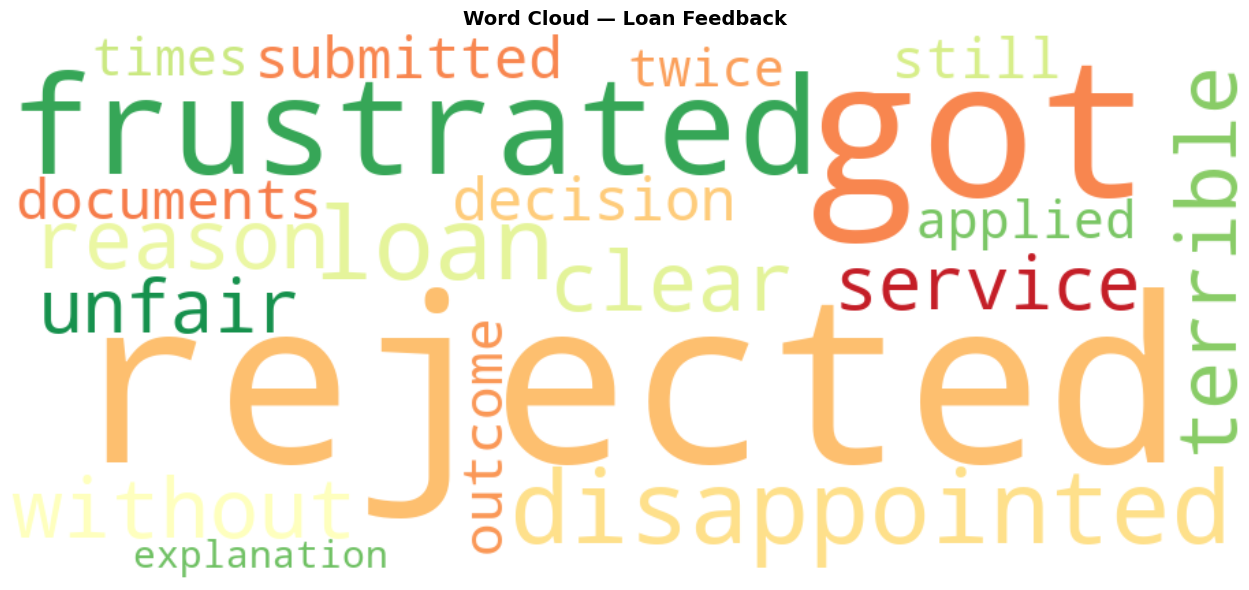

✅ Word cloud displayed


In [81]:
# ── Chart 2: Word cloud of negative feedback ─────────────────────
# Step 1: Filter DataFrame to only Negative sentiment rows
# Hint: df[df['sentiment'] == 'Negative']

neg_df = df[df['sentiment'] == 'Negative']

# Step 2: Flatten tokens from negative_df into one string
# Hint: ' '.join([token for token_list in negative_df['tokens'] for token in token_list])
# text_for_cloud = " ".join(all_tokens)
# print(text_for_cloud)

all_tokens = ' '.join([
    token 
    for token_list in neg_df['tokens'] 
    for token in token_list
])

# Step 3: Generate and display word cloud

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(all_tokens)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Loan Feedback", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")


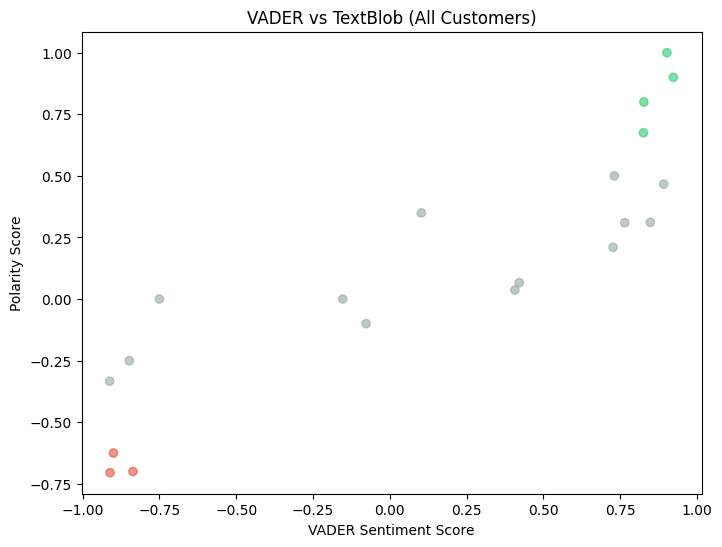

In [82]:
# ── Chart 3: VADER vs TextBlob scatter ───────────────────────────
sentiment_colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

colors = df['sentiment'].map(sentiment_colors)

plt.figure(figsize=(8,6))

plt.scatter(
    df['vader_compound'],
    df['tb_pol'],
    c=colors,
    alpha=0.6
)

plt.xlabel("VADER Sentiment Score")
plt.ylabel("Polarity Score")
plt.title("VADER vs TextBlob (All Customers)")

plt.show()

---
## ✅ Self-Check — Answer These Questions

After completing all 6 tasks, answer the following in the cell below:

1. How many customers were in the **Rejected — Negative** group?
2. What were the **top 3 words** in negative feedback?
3. Did VADER and TextBlob **agree** on more than 70% of customers?
4. Which group had the **highest count** in the bar chart?
5. What does a **high subjectivity score** mean for a customer's feedback?

**Your answers:**

1. 3
2. [('rejected', 3), ('got', 2), ('frustrated', 2)]
3. Yes
4. Approved — Neutral
5. 0.5742777777777778